In [369]:
import numpy as np
import pandas as pd
import seaborn as sns

In [370]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [371]:
train.shape

(1460, 81)

In [372]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [373]:
train.duplicated().sum()

np.int64(0)

In [374]:
quantitative = train.select_dtypes(include=['int64', 'float64']).columns
qualitative = train.select_dtypes(include=['str']).columns

print("Quantitative:")
print(quantitative)

print()

print("Qualitative:")
print(qualitative)

Quantitative:
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

Qualitative:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinTy

In [375]:
print('Пропуски в качественных: ', train[qualitative].columns[train[qualitative].isna().sum() > 0])
print('Пропуски в количественных: ', train[quantitative].columns[train[quantitative].isna().sum() > 0])

Пропуски в качественных:  Index(['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature'],
      dtype='str')
Пропуски в количественных:  Index(['LotFrontage', 'MasVnrArea', 'GarageYrBlt'], dtype='str')


In [376]:
qualitative_0 = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature']
quantitative_0 = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

In [377]:
train[quantitative_0].isna().sum()

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [378]:
train[quantitative_0].describe()

,LotFrontage,MasVnrArea,GarageYrBlt
count,1201.000000,1452.000000,1379.000000
mean,70.049958,103.685262,1978.506164
std,24.284752,181.066207,24.689725
min,21.000000,0.000000,1900.000000
25%,59.000000,0.000000,1961.000000
50%,69.000000,0.000000,1980.000000
75%,80.000000,166.000000,2002.000000
max,313.000000,1600.000000,2010.000000


In [379]:
train[train['GarageYrBlt'].isna()][
    ['GarageYrBlt', 'GarageType', 'GarageCars', 'GarageArea']].head(20)

,GarageYrBlt,GarageType,GarageCars,GarageArea
39,NaN,NaN,0,0
48,NaN,NaN,0,0
78,NaN,NaN,0,0
88,NaN,NaN,0,0
89,NaN,NaN,0,0
99,NaN,NaN,0,0
108,NaN,NaN,0,0
125,NaN,NaN,0,0
127,NaN,NaN,0,0
140,NaN,NaN,0,0


In [380]:
# Решил заполнить медианой по нескольким причинам:
#   1. Сам признак логически зависит от округа в котором расположен дом, поэтому будем групировать по округам
#   2. Выбрал медиану, т.к. она меньше всего зависит от выбросов, которые есть
train['LotFrontage'] = train['LotFrontage'].fillna(
    train.groupby('Neighborhood')['LotFrontage'].transform('median'))

# Здесь просто медианой
train['MasVnrArea'] = train['MasVnrArea'].fillna(train['MasVnrArea'].median())

# Здесь пропуски означают в целом отсутствие гаража, поэтому просто 0 вставил
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

In [381]:
train[quantitative_0].isna().sum()

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

In [ ]:
print(train[qualitative_0].isna().sum())

Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [392]:
quantitative_test = test.select_dtypes(include=['int64', 'float64']).columns
qualitative_test = test.select_dtypes(include=['str']).columns

print('Пропуски в качественных: ', test[qualitative_test].columns[test[qualitative_test].isna().sum() > 0])
print('Пропуски в количественных: ', test[quantitative_test].columns[test[quantitative_test].isna().sum() > 0])

Пропуски в качественных:  Index(['MSZoning', 'Alley', 'Utilities', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'KitchenQual', 'Functional', 'FireplaceQu',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType'],
      dtype='str')
Пропуски в количественных:  Index(['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt',
       'GarageCars', 'GarageArea'],
      dtype='str')


In [383]:
# Здесь пропуски логично заполнить "Ничем", т.к. они буквально и означают отсутствие объекта
train[qualitative_0] = train[qualitative_0].fillna('None')

In [384]:
print('Всего пропусков: ', sum(train.isna().sum() > 0))

Всего пропусков:  0


### Масштабирование

In [385]:
X_train = train.drop(['SalePrice', 'Id'], axis=1)
y_train = np.log1p(train['SalePrice'])
X_test = test.drop('Id', axis=1)

In [386]:
X_train_dum = pd.get_dummies(X_train)
X_test_dum = pd.get_dummies(X_test)

In [387]:
from sklearn import preprocessing

norm = preprocessing.MinMaxScaler()
X_train = norm.fit_transform(X_train_dum)
X_train = pd.DataFrame(data=X_train, columns=X_train_dum.columns)

X_test = norm.transform(X_test_dum)
X_test = pd.DataFrame(data=X_test, columns=X_test_dum.columns)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Alley_None
- BsmtCond_None
- BsmtExposure_None
- BsmtFinType1_None
- BsmtFinType2_None
- ...


## Бейз

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
pred1 = lr.predict(X_train)
print(root_mean_squared_error(y_train, pred1))

0.09452505095187397


In [ ]:
sub1 = lr.predict(X_test)
sub1

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Alley
- BldgType
- BsmtCond
- BsmtExposure
- BsmtFinType1
- ...
Feature names seen at fit time, yet now missing:
- Alley_Grvl
- Alley_None
- Alley_Pave
- BldgType_1Fam
- BldgType_2fmCon
- ...


In [ ]:
with open('sub', 'w') as f:
    

## Эксперименты

In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X_train, y_train)
pred2 = lasso.predict(X_train)
print(root_mean_squared_error(y_train, pred2))

0.11490124047831281


## Отбор признаков

In [ ]:
print('Кол-во качественных:', len(qualitative))
print('Кол-во количественных:', len(quantitative))

Кол-во качественных: 43
Кол-во количественных: 38


In [ ]:
quant_corr = train[quantitative].corr('pearson')
abs(quant_corr) <= 0.5

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,False,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
MSSubClass,True,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
LotFrontage,True,True,False,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
LotArea,True,True,True,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
OverallQual,True,True,True,True,False,True,False,False,True,True,...,True,True,True,True,True,True,True,True,True,False
OverallCond,True,True,True,True,True,False,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
YearBuilt,True,True,True,True,False,True,False,False,True,True,...,True,True,True,True,True,True,True,True,True,False
YearRemodAdd,True,True,True,True,False,True,False,False,True,True,...,True,True,True,True,True,True,True,True,True,False
MasVnrArea,True,True,True,True,True,True,True,True,False,True,...,True,True,True,True,True,True,True,True,True,True
BsmtFinSF1,True,True,True,True,True,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True


<Axes: >

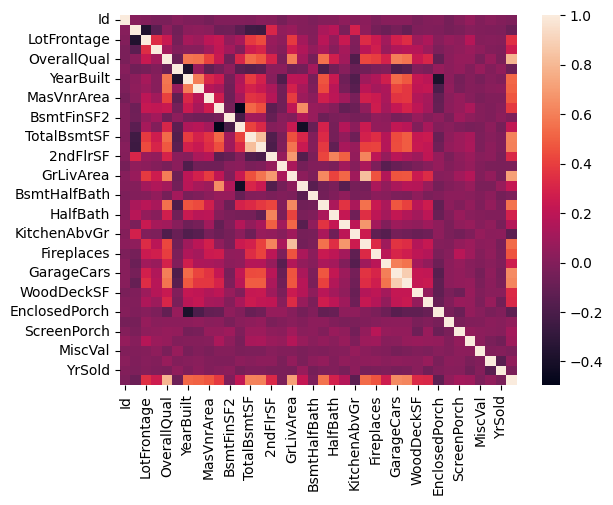

In [ ]:
sns.heatmap(train[quantitative].corr('pearson'))